In [1]:
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import numpy as np


In [2]:
vids_path = 'data/videos'
anno_path = 'data/gt_annotations'

In [3]:
def load_annotations(annos_path, latest=False):
    '''
    Combines all annotations into one dataframe and saves it to output_path
    '''

    if latest:
        # load latest annotation file
        anno_file = sorted(os.listdir(annos_path))[-2]
        combined_df = pd.read_csv(os.path.join(annos_path, anno_file), sep=';')
        print(f'loaded {anno_file}')
        print(f'Combined dataframe has {len(combined_df)} rows and {len(combined_df.columns)} columns')
        return combined_df

    combined_df = pd.DataFrame()
    for anno_file in os.listdir(annos_path):
        if anno_file.endswith('.csv'):
            df = pd.read_csv(os.path.join(annos_path, anno_file), sep=';')
            combined_df = pd.concat([combined_df, df], ignore_index=True)
            print(f'loaded {anno_file}')

    # combine audio and video appearances into one column
    combined_df['cKermit']  = combined_df['Kermit']
    combined_df['cPigs']  = combined_df['Pigs'] | combined_df['Audio_MissPiggy']
    combined_df['cCook'] = combined_df['Cook'] | combined_df['Audio_Cook']
    combined_df['cStatlerWaldorf'] = combined_df['StatlerWaldorf'] | combined_df['Audio_StatlerWaldorf']

    print(f'Combined dataframe has {len(combined_df)} rows')

    return combined_df

def load_videos(video_folder):
    '''
    Loads all videos in video_folder and returns a dictionary with episode names as keys and video objects as values
    '''

    video_dict = {}
    for file in os.listdir(video_folder):
        if file.endswith(".avi"):
            file_path = os.path.join(video_folder, file)
            episode_name = os.path.splitext(file)[0][-7::3]
            video_capture = cv2.VideoCapture(file_path)
            video_dict[episode_name] = video_capture
            
            #print video info
            frame_count = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
            fps = video_capture.get(cv2.CAP_PROP_FPS)
            width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
            print(f"Frame count: {frame_count}, FPS: {fps}, Resolution: {width}x{height}")
    return video_dict


In [20]:
anno_df = load_annotations(anno_path, latest=False)
video_dict = load_videos(vids_path)

loaded Muppets-02-04-04.csv
loaded Muppets-03-04-03.csv
loaded Muppets-02-01-01.csv
Combined dataframe has 115885 rows
Frame count: 38682, FPS: 25.0, Resolution: 720x544
Frame count: 38707, FPS: 25.0, Resolution: 720x544
Frame count: 38499, FPS: 25.0, Resolution: 704x544


,Annotation,Detection
Video,343,None
Frame_number,37592,None
Kermit,1,None
Pigs,1,None
Audio_Pigs,0,None
Cook,0,None
Audio_Cook,0,None
StatlerWaldorf,0,None
Audio_StatlerWaldorf,0,None
Audio_MissPiggy,0,None


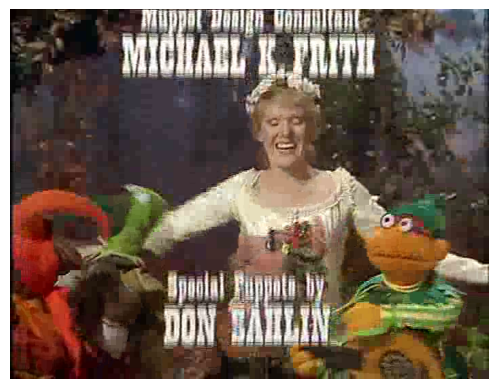

In [5]:
import cv2
import pandas as pd

# Function to add annotations as text onto a frame

def debug_frame(video_dict, vid_name, frame_num, annotation, detection):
    vid = video_dict[vid_name]
    anno = annotation[annotation['Video'] == int(vid_name)]
    anno = anno[anno['Frame_number'] == frame_num]
    anno = anno.T.rename(columns={anno.T.columns[0]: "Annotation" })
    if detection is not None:
        det = detection[detection['Video'] == int(vid_name)]
        det = det[det['Frame_number'] == frame_num]
        det = det.T.rename(columns={det.T.columns[0]: "Detection" })
        anno['Detection'] = det
    else:
        det = None
        anno['Detection'] = det
    display(anno)
    
    vid.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    success, frame = vid.read()
    if success:
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
    else:
        print("Failed to extract the frame.")

vid_name = '343'

frame_number = 37592
debug_frame(video_dict, vid_name, frame_number, anno_df, None)

In [6]:
from sklearn.metrics import precision_recall_fscore_support

def eval_prediction(y_true, y_pred, model_name=None, pos_label=1):
    precision, recall, fscore, support = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label=pos_label)
    
    eval_dict = {
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "f1": fscore,
        "support": support
    }

    return eval_dict

eval_prediction(y_true=anno_df['Kermit'], y_pred=anno_df['Kermit'], model_name="test")

{'model': 'test', 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': None}

In [7]:
# save anno_df to csv with timestamp
import datetime

def save_df_to_csv_stamped(df, path='data/annotations'):
    now = datetime.datetime.now()
    timestamp = now.strftime("%Y%m%d-%H%M%S")
    df.to_csv(f'{path}/annotations_features{timestamp}.csv', sep=';', index=False)

In [8]:
# majority classifier
from sklearn.dummy import DummyClassifier

for col in anno_df.columns[2:12]:
    print(col)
    y = anno_df[col]
    x = anno_df[col]
    dummy_clf = DummyClassifier(strategy="most_frequent")
    dummy_clf.fit(y, x)
    y_pred = dummy_clf.predict(x)
    eval = eval_prediction(y, y_pred, model_name="majority classifier", pos_label=0)
    print(eval)

Kermit
{'model': 'majority classifier', 'precision': 0.5971738791625539, 'recall': 1.0, 'f1': 0.7477881863127764, 'support': None}
Pigs
{'model': 'majority classifier', 'precision': 0.7187386357732869, 'recall': 1.0, 'f1': 0.8363559424495224, 'support': None}
Audio_Pigs
{'model': 'majority classifier', 'precision': 0.9218400955893813, 'recall': 1.0, 'f1': 0.9593306932298917, 'support': None}
Cook
{'model': 'majority classifier', 'precision': 0.9649851940360539, 'recall': 1.0, 'f1': 0.9821806260575296, 'support': None}
Audio_Cook
{'model': 'majority classifier', 'precision': 0.9926229934022547, 'recall': 1.0, 'f1': 0.9962978412764627, 'support': None}
StatlerWaldorf
{'model': 'majority classifier', 'precision': 0.9778430048314198, 'recall': 1.0, 'f1': 0.9887973943763708, 'support': None}
Audio_StatlerWaldorf
{'model': 'majority classifier', 'precision': 0.9875577952101408, 'recall': 1.0, 'f1': 0.9937399532130116, 'support': None}
Audio_MissPiggy
{'model': 'majority classifier', 'precisi

# Dominant Color HUE

In [31]:
from sklearn.cluster import MiniBatchKMeans

def calculate_dominant_colors_hsv_sklearn(image, k=5, mask=None, debug=False):
    '''
    calculates the dominant colors in an image using k-means clustering in HSV color space
    returns a dictionary with the dominant colors and their pixel counts
    '''
    colors = {}
    percentages = {}

    colors_sorted = np.zeros(k)
    counts_sorted = np.zeros(k)
    hsv_frame = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hue_values = hsv_frame[:, :, 0]  
    flattened_image = hue_values.reshape((-1, 1))  

    if mask is None:
        mask = np.ones(shape=(hsv_frame.shape[0], hsv_frame.shape[1]))
    flattened_mask = mask.flatten()

    masked_pixels = flattened_image[flattened_mask == 1]
    
    if np.sum(masked_pixels) == 0:
        for i, hue in enumerate(colors_sorted):
            colors[f'hue{i}'] = hue
        for i, counts in enumerate(counts_sorted):
            # return percentages since not all videos have the same amount of pixels
            percentages[f'pixel_percentage_hue{i}'] = counts
        return colors, percentages
    kmeans = MiniBatchKMeans(n_clusters=k, n_init='auto', batch_size=1024)
    kmeans.fit(masked_pixels)

    cluster_labels = kmeans.predict(masked_pixels)

    label, counts = np.unique(cluster_labels, return_counts=True)

    dominant_colors = kmeans.cluster_centers_

    dominant_colors_flattend = dominant_colors.flatten()
    p = np.argsort(counts)

    dominant_colors_sorted = dominant_colors_flattend[p][::-1]
    counts = counts[p][::-1]
    colors_sorted[:len(dominant_colors_sorted)] = dominant_colors_sorted
    counts_sorted[:len(counts)] = counts
    sum_counts = sum(counts_sorted)

    if debug:
        clustered_image = flattened_image.copy()
        clustered_image[flattened_mask == 1] = kmeans.cluster_centers_[cluster_labels]
        clustered_image[flattened_mask == 0] = 0
        clustered_image_hue = clustered_image.reshape(hue_values.shape)

        hsv_frame[:, :, 0]  = clustered_image_hue
        hsv_frame[:, :, 1][mask == 1]  = 200
        hsv_frame[:, :, 2][mask == 1]  = 100
        hsv_frame[:, :, 1][mask == 0]  = 0
        hsv_frame[:, :, 2][mask == 0]  = 0

        fig, axes = plt.subplots(1, 2, figsize=(5, 3))

        axes[0].imshow(cv2.cvtColor(hsv_frame, cv2.COLOR_HSV2RGB))
        axes[0].axis('off')
        axes[0].set_title('HSV Image')

        axes[1].imshow(cv2.cvtColor(clustered_image_hue, cv2.COLOR_BGR2RGB))
        axes[1].axis('off')
        axes[1].set_title('Clustered Image')

        plt.tight_layout()
        plt.show()
        
        print("Dominant Hues:", colors_sorted)
        print("Pixel Counts:", counts_sorted)
        print("Pixel Percentage:", counts_sorted / sum_counts)
        print("count sum:", sum(counts_sorted))


    for i, hue in enumerate(colors_sorted):
        colors[f'hue{i}'] = hue
    for i, counts in enumerate(counts_sorted):
        # return percentages since not all videos have the same amount of pixels
        percentages[f'pixel_percentage_hue{i}'] = counts / sum_counts
    return colors, percentages

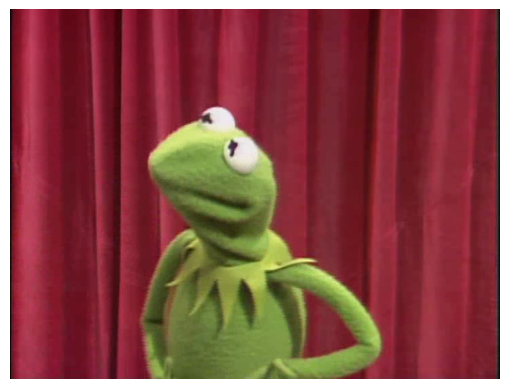

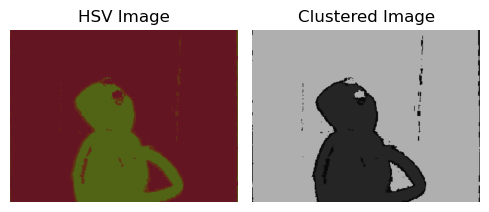

Dominant Hues: [175.20545587  37.22564949  10.84639285]
Pixel Counts: [303123.  75484.  13073.]
Pixel Percentage: [0.77390472 0.19271855 0.03337674]
count sum: 391680.0
{'hue0': 175.20545586683048, 'hue1': 37.22564949170218, 'hue2': 10.846392853675109}


In [10]:
video_capture = video_dict['244']
frame_number = 31715

video_capture.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
success, frame = video_capture.read()

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

hues, counts = calculate_dominant_colors_hsv_sklearn(frame, k=3, debug=True)
print(hues)

# Detect scene cuts

tried with simple negative convolution, but does not work use background detection instead

In [11]:
from scipy.signal import find_peaks

def get_frame_differences(video, peak_threshold=1000, peak_height=10000000):
    '''
    Returns a list of frame numbers where the camera switches
    '''
    pixels = video.get(cv2.CAP_PROP_FRAME_WIDTH) * video.get(cv2.CAP_PROP_FRAME_HEIGHT)
    video.set(cv2.CAP_PROP_POS_FRAMES, 0)

    change = np.zeros(int(video.get(cv2.CAP_PROP_FRAME_COUNT)), np.float32)
    i = 0
    ret, previous_frame = video.read()
    while(1):
        ret, frame = video.read()
        if ret:
            pf_gray = cv2.cvtColor(previous_frame, cv2.COLOR_BGR2GRAY)
            f_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            difference = cv2.absdiff(pf_gray, f_gray)
            a = np.sum(difference)
            change[i] = a
            i = i + 1
            previous_frame = frame
        else:
            break
    return change / pixels

def get_background_subtraction(video):
    '''
    Returns a list of frame numbers where the camera switches
    '''
    pixels = video.get(cv2.CAP_PROP_FRAME_WIDTH) * video.get(cv2.CAP_PROP_FRAME_HEIGHT)
    video.set(cv2.CAP_PROP_POS_FRAMES, 0)

    fgbg = cv2.createBackgroundSubtractorMOG2()
    change = np.zeros(int(video.get(cv2.CAP_PROP_FRAME_COUNT)), np.float32)
    i = 0
    while(1):
        ret, frame = video.read()
        if ret:
            fgmask = fgbg.apply(frame)
            a = np.sum(fgmask)
            change[i] = a
            i = i + 1
        else:
            break

    return (change / pixels)[1:]


In [12]:
# TODO why is anno df 1 row shorter than video?
def add_video_change_features_to_df(video_dict, anno_df):
    '''
    Returns a dataframe with the background_substraction_change feature
    '''
    if 'background_substraction_change' not in anno_df.columns:
        anno_df['background_substraction_change'] = None
        for vid in video_dict:
            print(f'processing {vid}')
            change = get_background_subtraction(video_dict[vid])
            anno_df.loc[anno_df['Video'] == int(vid), 'background_substraction_change'] = change
    else:
        print('background_substraction_change feature already in dataframe')
    if anno_df['background_substraction_change'].hasnans:
        print('WARNING: dataframe contains NaNs')
    return anno_df


In [37]:
anno_df = add_video_change_features_to_df(video_dict, anno_df)

processing 211


KeyboardInterrupt: 

In [13]:
def visualize_camera_switches(video, camera_switches):
    video.set(cv2.CAP_PROP_POS_FRAMES, 0)

    for i, frame_number in enumerate(camera_switches['peaks']):
        if i % 20 != 0:
            continue
        fps = video.get(cv2.CAP_PROP_FPS)
        time_at_frame = frame_number / 25  # Time in seconds

        time_window_before = max(0, time_at_frame - 0.2)
        time_window_after = min(time_at_frame + 0.2, video.get(cv2.CAP_PROP_FRAME_COUNT) / fps)

        frame_before = int(time_window_before * fps)
        frame_after = int(time_window_after * fps)

        video.set(cv2.CAP_PROP_POS_FRAMES, frame_before)
        ret, frame_prev = video.read()

        video.set(cv2.CAP_PROP_POS_FRAMES, frame_after)
        ret, frame_next = video.read()

        fig, axes = plt.subplots(1, 2, figsize=(4, 3))

        axes[0].imshow(cv2.cvtColor(frame_prev, cv2.COLOR_BGR2RGB))
        axes[0].axis('off')
        axes[0].set_title('Frame before {:.2f}s'.format(time_window_before))

        axes[1].imshow(cv2.cvtColor(frame_next, cv2.COLOR_BGR2RGB))
        axes[1].axis('off')
        axes[1].set_title('Frame after {:.2f}s'.format(time_window_after))

        plt.tight_layout()
        plt.show()

def get_camera_switches_from_frame_difference(frame_difference=None, debug=False, peak_height=20, peak_distance=25):
    abs_gradiant = abs(np.gradient(frame_difference))
    peaks, _ = find_peaks(abs_gradiant, height=peak_height, distance=peak_distance)
    camera_switches = {}
    camera_switches['peaks'] = peaks
    if debug:
        n = 2000
        peaks = np.where(peaks<n, peaks, 0)
        plt.plot(frame_difference[:n])
        plt.plot(abs_gradiant[:n])
        plt.plot(peaks, abs_gradiant[peaks], "x")
        plt.show()
    return camera_switches

In [14]:
def add_camera_switch_features_to_df(video_dict, anno_df):
    '''
    Returns a dataframe with the camera_switches feature
    '''
    if 'camera_switches' not in anno_df.columns:
        anno_df['camera_switches'] = None
        for vid in video_dict:
            print(f'processing {vid}')
            camera_switches = get_camera_switches_from_frame_difference(anno_df.loc[anno_df['Video'] == int(vid), 'background_substraction_change'], debug=False, peak_height=20, peak_distance=25)
            is_switch = np.zeros(anno_df.loc[anno_df['Video'] == int(vid), 'background_substraction_change'].shape[0])
            is_switch[camera_switches['peaks']] = 1
            anno_df.loc[anno_df['Video'] == int(vid), 'camera_switches'] = is_switch
    else:
        print('camera_switches feature already in dataframe')
    if anno_df['camera_switches'].hasnans:
        print('camera_switches: contains NaNs')
    return anno_df

In [ ]:
anno_df = add_camera_switch_features_to_df(video_dict, anno_df)
save_df_to_csv_stamped(anno_df)


NameError: name 'video_dict' is not defined

# Optical flow
## detect foreground

if variance is low -> camera movement
if variance is high -> check static vs non static -> static background, non static-> foreground -> cluster b
if 

In [15]:
def calculate_optical_flow(video, frame_number, debug=False):
    video.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = video.read()
    if not ret:
        print("Failed to extract the frame.")
        return None, None

    prev_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)


    video.set(cv2.CAP_PROP_POS_FRAMES, frame_number + 1)
    ret, frame = video.read()
    if not ret:
        print("Failed to extract the frame: " + 
                str(frame_number) + " of " +
                str(video.get(cv2.CAP_PROP_FRAME_COUNT)) + 
                " frames.")
        return None, None

    next_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(prev_frame, next_frame, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    
    if debug:
        hsv = np.zeros_like(frame)
        hsv[..., 1] = 255
        hsv[..., 0] = ang * 180 / np.pi / 2
        hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
        rgb_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
        plt.figure(figsize=(5, 2))
        plt.imshow(rgb_flow)
        plt.axis('off')
        plt.show()

    return mag, ang

In [39]:
def calc_and_save_optical_flow(vid_dict, path='data/optical_flow/'):
    for video_name, video in vid_dict.items():
        
        output_video_path_mag = path + video_name+'mag.mp4'
        output_video_path_ang = path + video_name+'ang.mp4'
        #check if video already exists
        if os.path.isfile(output_video_path_mag) or os.path.isfile(output_video_path_ang):
            print("Optical flow for video already exists: " + video_name)
            continue
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        fourcc = cv2.VideoWriter_fourcc('a', 'v', 'c', '1')

        width = video.get(cv2.CAP_PROP_FRAME_WIDTH)
        height = video.get(cv2.CAP_PROP_FRAME_HEIGHT)   
        output_video_mag = cv2.VideoWriter(output_video_path_mag, fourcc, 25.0, (int(width), int(height)), isColor=False)
        output_video_ang = cv2.VideoWriter(output_video_path_ang, fourcc, 25.0, (int(width), int(height)), isColor=False)

        for frame_number in range(int(video.get(cv2.CAP_PROP_FRAME_COUNT))):
            if frame_number % 100 == 0:
                print(str(frame_number) + "/" + str(video.get(cv2.CAP_PROP_FRAME_COUNT)))
                print(frame_number / video.get(cv2.CAP_PROP_FRAME_COUNT))
                debug = False
            else:
                debug = False
            video.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
            ret, frame = video.read()
            if not ret:
                print("Failed to extract the frame: " + 
                    str(frame_number) + " from video: " + 
                    video_name + "which has " + 
                    str(video.get(cv2.CAP_PROP_FRAME_COUNT)) + 
                    " frames.")
                break
            mag, ang = calculate_optical_flow(video, frame_number, debug=debug)
            if mag is None or ang is None:
                print("No optical flow for frame: " + str(frame_number))
                break
            capped_mag = np.clip(mag, 0, 100)
            capped_ang = np.clip(ang, 0, 10)
            normalized_mag = cv2.normalize(capped_mag, None, 0, 255, cv2.NORM_MINMAX)
            normalized_ang = cv2.normalize(capped_ang, None, 0, 255, cv2.NORM_MINMAX)
            uint8_mag = np.uint8(normalized_mag)
            uint8_ang = np.uint8(normalized_ang)

            output_video_mag.write(uint8_mag)
            output_video_ang.write(uint8_ang)
        
        output_video_mag.release()
        output_video_ang.release()
        break
calc_and_save_optical_flow(video_dict)

0/38682.0
0.0
100/38682.0
0.002585181738276201
200/38682.0
0.005170363476552402
300/38682.0
0.007755545214828603
400/38682.0
0.010340726953104803
500/38682.0
0.012925908691381004
600/38682.0
0.015511090429657206
700/38682.0
0.018096272167933407
800/38682.0
0.020681453906209606
900/38682.0
0.023266635644485806
1000/38682.0
0.02585181738276201
1100/38682.0
0.028436999121038208
1200/38682.0
0.03102218085931441
1300/38682.0
0.03360736259759061
1400/38682.0
0.036192544335866814
1500/38682.0
0.03877772607414301
1600/38682.0
0.04136290781241921
1700/38682.0
0.043948089550695416
1800/38682.0
0.04653327128897161
1900/38682.0
0.049118453027247815
2000/38682.0
0.05170363476552402


KeyboardInterrupt: 

In [19]:
def calculate_foreground_mask(mag, debug=False, img=None):
    # average kernel, convolute over the magnitude image
    # kernel size is 50x50
    # create mask by checking if magnitude is above the mean of the convoluted image
    kernel = np.ones((50, 50)) / 2500
    convoluted = cv2.filter2D(mag, -1, kernel)
    mask = (convoluted > max(np.mean(convoluted),3)).astype(np.uint8)
    print('im here')
    if debug:
        if img is None:
            print("Please provide an image for debugging.")
            return mask
        # plot side by side the image, the convoluted image and the masked image
        fig, axes = plt.subplots(1, 3, figsize=(5, 2))
        axes[0].imshow(img)
        axes[0].axis('off')
        axes[0].set_title('Original Image')

        axes[1].imshow(convoluted, cmap='gray')
        axes[1].axis('off')
        axes[1].set_title('Convoluted Image')

        axes[2].imshow(mask, cmap='gray')
        axes[2].axis('off')
        axes[2].set_title('Foreground Mask')
        
        plt.tight_layout()
        plt.show()
    return mask
    

In [20]:
def get_motion_features(video_name, path='data/optical_flow/'):
    '''
    Returns a dataframe with the camera_switches feature
    '''
    mag_path = path + video_name + 'mag.mp4'
    ang_path = path + video_name + 'ang.mp4'
    
    if not os.path.isfile(mag_path) or not os.path.isfile(ang_path):
        print("Optical flow for video does not exist: " + video_name)
        print("Please run calc_and_save_optical_flow first.")
        return None
    
    mag_video = cv2.VideoCapture(mag_path)
    ang_video = cv2.VideoCapture(ang_path)
    ang_means = np.zeros(int(ang_video.get(cv2.CAP_PROP_FRAME_COUNT)), np.float32)
    mag_means = np.zeros(int(mag_video.get(cv2.CAP_PROP_FRAME_COUNT)), np.float32)
    ang_stds = np.zeros(int(ang_video.get(cv2.CAP_PROP_FRAME_COUNT)), np.float32)
    mag_stds = np.zeros(int(mag_video.get(cv2.CAP_PROP_FRAME_COUNT)), np.float32)

    i = 0
    while(1):
        if i % 3000 == 0:
            print(str(i) + "/" + str(ang_video.get(cv2.CAP_PROP_FRAME_COUNT)))
        ret, frame = mag_video.read()
        if not ret:
            print("Failed to extract the frame.")
            print("Video has " + str(mag_video.get(cv2.CAP_PROP_FRAME_COUNT)) + " frames., i=" + str(i))
            break
        mag = frame
        ret, frame = ang_video.read()
        if not ret:
            print("Failed to extract the frame.")
            print("Should not happen")
            break
        ang = frame
        ang_means[i] = np.mean(ang)
        mag_means[i] = np.mean(mag)
        ang_stds[i] = np.std(ang)
        mag_stds[i] = np.std(mag)
        i = i + 1
    return ang_means, mag_means, ang_stds, mag_stds

def add_motion_features_to_df(video_dict, anno_df):
    '''
    Returns a dataframe with the camera_switches feature
    '''
    if 'of_ang_means' not in anno_df.columns:
        anno_df['of_ang_means'] = None
    elif 'of_mag_means' not in anno_df.columns:
        anno_df['of_mag_means'] = None
    elif 'of_ang_stds' not in anno_df.columns:
        anno_df['of_ang_stds'] = None
    elif 'of_mag_stds' not in anno_df.columns:
        anno_df['of_mag_stds'] = None
    else:
        print('some motion features already in dataframe')
        return anno_df
    for vid in video_dict:
        print(f'processing {vid}')
        ang_means, mag_means, ang_stds, mag_stds = get_motion_features(vid)
        anno_df.loc[anno_df['Video'] == int(vid), 'of_ang_means'] = ang_means
        anno_df.loc[anno_df['Video'] == int(vid), 'of_mag_means'] = mag_means
        anno_df.loc[anno_df['Video'] == int(vid), 'of_ang_stds'] = ang_stds
        anno_df.loc[anno_df['Video'] == int(vid), 'of_mag_stds'] = mag_stds
    if anno_df['of_ang_means'].hasnans or anno_df['of_mag_means'].hasnans or anno_df['of_ang_stds'].hasnans or anno_df['of_mag_stds'].hasnans:
        print('motion features: contains NaNs')
    return anno_df

In [21]:
anno_df = add_motion_features_to_df(video_dict, anno_df)
save_df_to_csv_stamped(anno_df)

NameError: name 'video_dict' is not defined

In [36]:
# add dominant colors to dataframe
import time

def add_dominant_colors_to_df(video_dict, anno_df, k=5):
    '''
    Returns a dataframe with the dominant colors feature
    '''
    for i in range(k):
        if f'hue{i}' not in anno_df.columns:
            anno_df[f'hue{i}'] = None
        else:
            print(f'hue{i} already in dataframe')
            return anno_df
    for i in range(k):
        if f'pixel_percentage_hue{i}' not in anno_df.columns:
            anno_df[f'pixel_percentage_hue{i}'] = None
        else:
            print(f'pixel_percentage_hue{i} already in dataframe')
            return anno_df
        
    old_t = time.time()

    for vid in video_dict:
        hues = np.zeros((anno_df.loc[anno_df['Video'] == int(vid), 'Video'].shape[0], k))
        pixel_percentages = np.zeros((anno_df.loc[anno_df['Video'] == int(vid), 'Video'].shape[0], k))
        print(f'processing {vid}')
        i = 0
        video_dict[vid].set(cv2.CAP_PROP_POS_FRAMES, 1)
        while(1):
            success, frame = video_dict[vid].read()
            if i % 1000 == 0:
                t = time.time()
                print_t = t - old_t
                print(f"time = {print_t}")
                old_t = t
                print(str(i) + "/" + str(video_dict[vid].get(cv2.CAP_PROP_FRAME_COUNT)))
            if success:
                hueies, percentages = calculate_dominant_colors_hsv_sklearn(frame, k=5, mask=None, debug=False) 
                for j in range(k):
                    hues[i,j] = hueies[f'hue{j}']
                    pixel_percentages[i,j] = percentages[f'pixel_percentage_hue{j}']
                i = i + 1
            else:
                print("Failed to extract the frame.")
                print("Video has " + str(video_dict[vid].get(cv2.CAP_PROP_FRAME_COUNT)) + " frames., i=" + str(i))
                break

        for i in range(k):
            anno_df.loc[anno_df['Video'] == int(vid), f'hue{i}'] = hues[i]
            anno_df.loc[anno_df['Video'] == int(vid), f'pixel_percentage_hue{i}'] = pixel_percentages[i]
        
    for i in range(k):
        if anno_df[f'hue{i}'].hasnans or anno_df[f'pixel_percentage_hue{i}'].hasnans:
            print(f'dominant colors: contains NaNs for hue{i}')
    return anno_df

In [37]:
for i in range(5):
    try:
        anno_df.pop(f'hue{i}')
        anno_df.pop(f'pixel_percentage_hue{i}')
    except:
        pass
anno_df = add_dominant_colors_to_df(video_dict, anno_df)

processing 211
time = 0.0023772716522216797
0/38682.0
time = 63.69684076309204
1000/38682.0


KeyboardInterrupt: 

In [ ]:
save_df_to_csv_stamped(anno_df)

NameError: name 'anno_df' is not defined

In [ ]:
video_capture = video_dict['244']
frame_number = 31715

video = video_dict['244']
feature_df = anno_df.loc[:,['Video', 'Frame_number']]
feature_df.loc[:,'mean_mag'] = np.nan
feature_df.loc[:,'std_mag'] = np.nan
feature_df.loc[:,'mean_ang'] = np.nan
feature_df.loc[:,'std_ang'] = np.nan
feature_df.loc[:,'hue_0'] = np.nan
feature_df.loc[:,'hue_1'] = np.nan
feature_df.loc[:,'hue_2'] = np.nan
feature_df.loc[:,'hue_3'] = np.nan
feature_df.loc[:,'hue_4'] = np.nan
feature_df.loc[:,'count_0'] = np.nan
feature_df.loc[:,'count_1'] = np.nan
feature_df.loc[:,'count_2'] = np.nan
feature_df.loc[:,'count_3'] = np.nan
feature_df.loc[:,'count_4'] = np.nan
feature_df.loc[:,'hue_f_0'] = np.nan
feature_df.loc[:,'hue_f_1'] = np.nan
feature_df.loc[:,'hue_f_2'] = np.nan
feature_df.loc[:,'hue_b_0'] = np.nan
feature_df.loc[:,'hue_b_1'] = np.nan
feature_df.loc[:,'hue_b_2'] = np.nan
feature_df.loc[:,'count_f_0'] = np.nan
feature_df.loc[:,'count_f_1'] = np.nan
feature_df.loc[:,'count_f_2'] = np.nan
feature_df.loc[:,'count_b_0'] = np.nan
feature_df.loc[:,'count_b_1'] = np.nan
feature_df.loc[:,'count_b_2'] = np.nan

#todo add foreground and background pixel counts (more like movement but still)
feature_df.loc[:,'movement_pixels'] = np.nan

for video_name, video in video_dict.items():
    video_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
    mean_mag = np.zeros(video_frames-1, np.float32)
    std_mag = np.zeros(video_frames-1, np.float32)
    mean_ang = np.zeros(video_frames-1, np.float32)
    std_ang = np.zeros(video_frames-1, np.float32)
    hues = np.zeros((video_frames-1, 5), np.float32)
    counts = np.zeros((video_frames-1, 5), np.float32)
    hues_fs = np.zeros((video_frames-1, 3), np.float32)
    hues_bs = np.zeros((video_frames-1, 3), np.float32)
    counts_fs = np.zeros((video_frames-1, 3), np.float32)
    counts_bs = np.zeros((video_frames-1, 3), np.float32)
    movement_pixels = np.zeros(video_frames-1, np.float32)

    output_video_path_mag = video_name+'mag.mp4'
    output_video_path_ang = video_name+'ang.mp4'

    for frame_number in range(int(video.get(cv2.CAP_PROP_FRAME_COUNT)+1)):
        if frame_number % 1000 == 0:
            print(str(frame_number) + "/" + str(video.get(cv2.CAP_PROP_FRAME_COUNT)))
            print(frame_number / video.get(cv2.CAP_PROP_FRAME_COUNT))
            debug = True
        else:
            debug = False
        video.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
        ret, frame = video.read()
        mag, ang = calculate_optical_flow(video, frame_number, debug=debug)

        #cut it at 100

        print(mag.dtype)
        print(ang.dtype)
        print(np.max(mag))
        print(np.max(ang))

        # foreground_mask = calculate_foreground_mask(mag, debug=debug, img=frame)

        # hue, count = calculate_dominant_colors_hsv_sklearn(frame, k=5, debug=debug)
        # hue_f, count_f = calculate_dominant_colors_hsv_sklearn(frame, mask=foreground_mask, k=3, debug=debug)
        # hue_b, count_b = calculate_dominant_colors_hsv_sklearn(frame, mask=np.logical_not(foreground_mask), k=3, debug=debug)

        mean_mag[frame_number] = np.mean(mag)
        std_mag[frame_number] = np.std(mag)
        mean_ang[frame_number] = np.mean(ang)
        std_ang[frame_number] = np.std(ang)
        # hues[frame_number] = hue
        # counts[frame_number] = count
        # hues_fs[frame_number] = hue_f
        # hues_bs[frame_number] = hue_b
        # counts_fs[frame_number] = count_f
        # counts_bs[frame_number] = count_b
        # movement_pixels[frame_number] = np.sum(foreground_mask)

    vid_name = int(video_name)  
    vid_feature_df = feature_df.loc[feature_df['Video']==vid_name]
    vid_feature_df.loc[:,'mean_mag'] = mean_mag
    vid_feature_df.loc[:,'std_mag'] = std_mag
    vid_feature_df.loc[:,'mean_ang'] = mean_ang
    vid_feature_df.loc[:,'std_ang']= std_ang

    for i in range(5):
        vid_feature_df.loc[:,'hue_' + str(i)] = hues[:, i]
        vid_feature_df.loc[:,'count_' + str(i)] = counts[:, i]
    for i in range(3):
        vid_feature_df.loc[:,'hue_f_' + str(i)] = hues_fs[:, i]
        vid_feature_df.loc[:,'hue_b_' + str(i)] = hues_bs[:, i]
        vid_feature_df.loc[:,'count_f_' + str(i)] = counts_fs[:, i]
        vid_feature_df.loc[:,'count_b_' + str(i)] = counts_bs[:, i]
    feature_df.loc[feature_df['Video']==vid_name] = vid_feature_df
    vid_feature_df.to_csv('data/features_' + str(vid_name) + '.csv', sep=';')
    feature_df.to_csv('data/features.csv', sep=';')
    break
      
    

NameError: name 'video_dict' is not defined

In [ ]:
#calculate_optical_flow and write it into the file system



In [ ]:
video_name = '244'
video_capture = cv2.VideoCapture(video_name+'mag.mp4')

while True:
    ret, frame = video_capture.read()
    if not ret:
        break
    print(video_capture.get(cv2.CAP_PROP_POS_FRAMES))

In [ ]:
#read the video 

vid = cv2.VideoCapture('343mag.mp4')

#read the frame
print(vid.get(cv2.CAP_PROP_FRAME_COUNT))
vid.set(cv2.CAP_PROP_POS_FRAMES, 99)
success, frame = vid.read()
print(success)
plt.imshow(frame)

In [ ]:
display(feature_df[feature_df['Video'] == int(343)])

filtered_df = feature_df[feature_df['hue_0'] != 0]

not_nan = feature_df[feature_df['hue_0'].notna()]
# Display the resulting DataFrame
display(filtered_df)
display(feature_df)
display(not_nan)

In [ ]:
plt.plot(mean_mag[:1000])
plt.plot(std_mag[:1000])
plt.plot(mean_ang[:1000])
plt.plot(std_ang[:1000])
plt.legend(['mean_mag', 'std_mag', 'mean_ang', 'std_ang'])

In [ ]:
peaks, _ = find_peaks(abs(np.gradient(change[0:1000])), threshold=100, height=500000)
print(peaks)
plt.plot(change[0:1000])
plt.plot(abs(np.gradient(change[0:1000])))
plt.plot(peaks, abs(np.gradient(change[0:1000]))[peaks], "x")

#[ 44 193 218 376 539 666 951]


In [ ]:
import cv2


cap = video_dict['343']
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
print(cap)

frame_number = 218  

for frame_number in peaks:
    fps = cap.get(cv2.CAP_PROP_FPS)
    print(fps) 
    time_at_frame = frame_number / 25  # Time in seconds

    time_window_before = max(0, time_at_frame - 0.2)
    time_window_after = min(time_at_frame + 0.2, cap.get(cv2.CAP_PROP_FRAME_COUNT) / fps)

    frame_before = int(time_window_before * fps)
    frame_after = int(time_window_after * fps)

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_before)
    ret, frame_prev = cap.read()

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_after)
    ret, frame_next = cap.read()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(cv2.cvtColor(frame_prev, cv2.COLOR_BGR2RGB))
    axes[0].axis('off')
    axes[0].set_title('Frame before {:.2f}s'.format(time_window_before))

    axes[1].imshow(cv2.cvtColor(frame_next, cv2.COLOR_BGR2RGB))
    axes[1].axis('off')
    axes[1].set_title('Frame after {:.2f}s'.format(time_window_after))

    plt.tight_layout()
    plt.show()


In [ ]:

for video_capture in video_dict.values():
    video_capture.release()
